# Assignment 4 — PCA: How Few Components Can You Get Away With?
Feature Engineering & MLOps · Dimensionality Reduction (PCA Practical)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

RANDOM_STATE = 42

df = pd.read_csv('../data/raw/Unit-02/pca_regression_data.csv')
print(df.shape)
df.head()

(800, 62)


,student_id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,score
0,1,1.006103,2.625090,-0.021036,6.231392,3.147998,-0.044665,-3.420442,1.567874,0.189118,...,3.515794,-1.345712,1.038361,1.358821,4.510162,-0.345406,3.255827,0.607355,1.126482,-0.319225
1,2,4.442871,-2.006560,-1.181818,1.695413,-3.168459,-5.989658,-2.662836,-4.174475,-2.323000,...,1.640106,4.207556,-3.367389,1.398171,1.162581,0.681762,-4.742943,2.150911,-5.587529,3.418536
2,3,1.723720,-3.352754,1.020613,0.533918,3.769766,-0.004683,-0.019345,0.515542,-0.225922,...,0.874327,-0.868329,1.769608,-1.165895,1.189553,3.324718,-1.858829,2.980939,1.121997,2.618471
3,4,0.411140,2.025221,-2.621914,-5.890728,-1.068567,3.413866,3.243600,4.476142,2.650463,...,-0.967199,-1.848642,1.535045,-4.300282,-5.457053,1.066226,2.996332,4.766362,1.312600,-3.740992
4,5,1.011855,3.029584,-2.574027,-1.983156,-1.696483,-2.258118,-1.735768,0.689373,-0.849770,...,-1.185252,-0.883210,0.022223,-1.336599,2.028197,-2.490620,1.414216,-1.392051,0.611356,1.294747


## Section 4.1 — Baseline: all 60 raw features

In [2]:
feature_cols = [f'feature_{i}' for i in range(1, 61)]
X = df[feature_cols]
y = df['score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)
baseline_r2 = r2_score(y_test, baseline_model.predict(X_test_scaled))
print(f'Baseline R2 (all 60 features): {baseline_r2:.4f}')

Baseline R2 (all 60 features): 0.8584


## Section 4.2 — PCA: explained variance and the scree plot

In [3]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

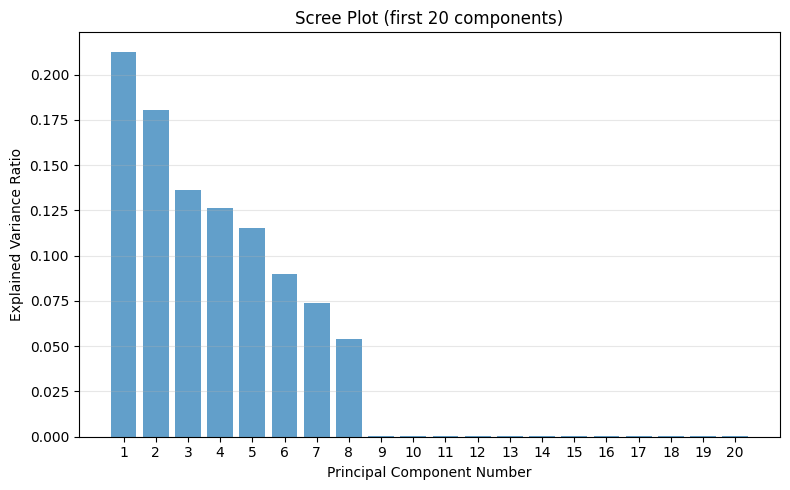

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 21), evr[:20], alpha=0.7, label='Explained variance ratio')
plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (first 20 components)')
plt.xticks(range(1, 21))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

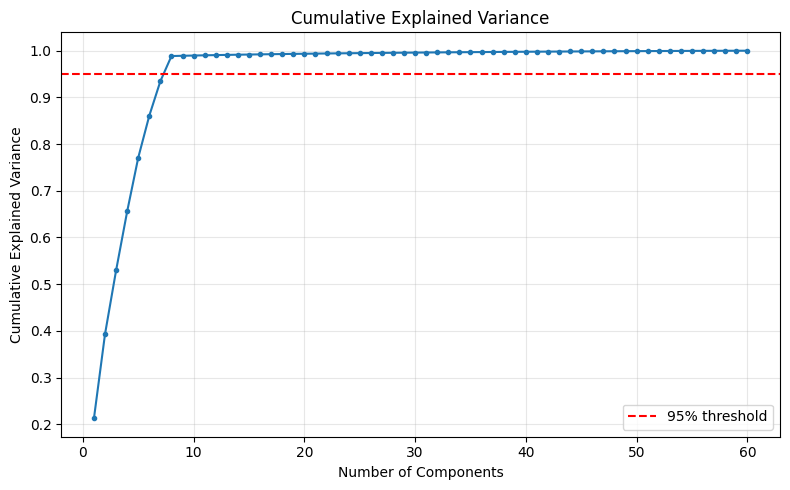

Components needed for 95% variance: 8
First 15 EVR: [0.2127 0.1804 0.1364 0.1263 0.1151 0.0901 0.0738 0.0537 0.0006 0.0005
 0.0005 0.0005 0.0004 0.0004 0.0004]


In [5]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_evr) + 1), cum_evr, marker='o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_95 = np.argmax(cum_evr >= 0.95) + 1
print(f'Components needed for 95% variance: {n_95}')
print('First 15 EVR:', np.round(evr[:15], 4))

**Visual elbow estimate (written BEFORE running 4.3):** Looking at the scree plot, the explained variance drops steeply for the first few components and then flattens out. The elbow appears to be around **4–6 components**, after which additional components contribute very little variance.

## Section 4.3 — Find the smallest component count that matches baseline accuracy

In [6]:
component_counts = [2, 4, 6, 8, 10, 12, 15, 20, 30, 40]
test_r2_scores = []

for n in component_counts:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_pca, y_train)
    r2 = r2_score(y_test, model.predict(X_test_pca))
    test_r2_scores.append(r2)
    print(f'n_components={n:>3d}  ->  Test R2 = {r2:.4f}')

n_components=  2  ->  Test R2 = 0.2409
n_components=  4  ->  Test R2 = 0.4989
n_components=  6  ->  Test R2 = 0.6946
n_components=  8  ->  Test R2 = 0.8716
n_components= 10  ->  Test R2 = 0.8722
n_components= 12  ->  Test R2 = 0.8718
n_components= 15  ->  Test R2 = 0.8724
n_components= 20  ->  Test R2 = 0.8725
n_components= 30  ->  Test R2 = 0.8665
n_components= 40  ->  Test R2 = 0.8634


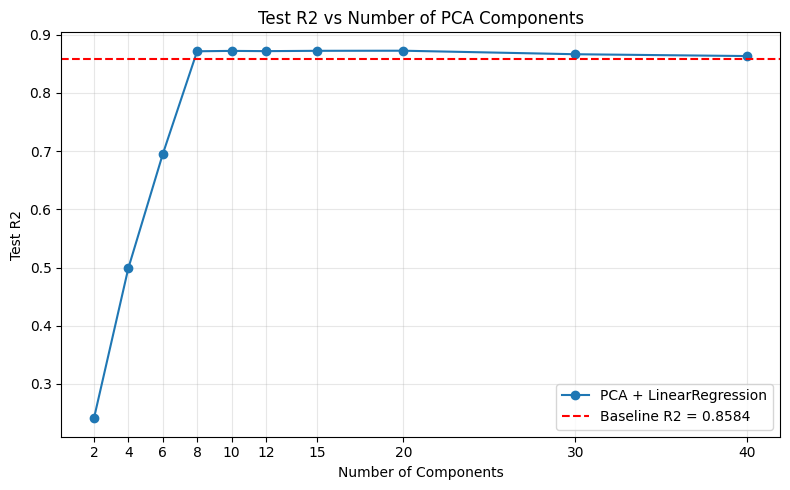

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(component_counts, test_r2_scores, marker='o', label='PCA + LinearRegression')
plt.axhline(y=baseline_r2, color='r', linestyle='--', label=f'Baseline R2 = {baseline_r2:.4f}')
plt.xlabel('Number of Components')
plt.ylabel('Test R2')
plt.title('Test R2 vs Number of PCA Components')
plt.xticks(component_counts)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
smallest_match = None
for n, r2 in zip(component_counts, test_r2_scores):
    if r2 >= baseline_r2 - 0.01:
        smallest_match = n
        break

print(f'Baseline R2:            {baseline_r2:.4f}')
print(f'Threshold (baseline-1%): {baseline_r2 - 0.01:.4f}')
print(f'Smallest matching components: {smallest_match}')

Baseline R2:            0.8584
Threshold (baseline-1%): 0.8484
Smallest matching components: 8


**Comparison with elbow estimate:** The visual scree-plot elbow estimate was 4–6 components. The smallest component count matching baseline accuracy is **8 components** (test R2 = 0.8716 vs baseline 0.8584). The estimates roughly agree — both point to a single-digit number of components — with the accuracy-based answer (8) sitting slightly above the visual estimate because accuracy needs a bit more of the signal than the variance elbow alone suggests. The 95% cumulative-variance threshold independently confirms 8, matching the accuracy answer exactly.

## Section 4.4 — Explain it

The baseline Linear Regression using all 60 raw features achieved a test R2 of 0.8584, while using only 8 principal components actually *exceeded* that with a test R2 of 0.8716 — meaning 8 components are enough to match (and slightly beat) the full 60-feature model. The scree plot shows why: the first 8 components capture essentially all the meaningful variance (components 1–8 have explained-variance ratios of 0.21, 0.18, 0.14, 0.13, 0.12, 0.09, 0.07, and 0.05, summing to ~98.8%), while components 9 and beyond drop to ~0.0006 each — they contribute almost nothing. This tells us the original 60 features were not independent at all; they were generated from a small number of true latent factors (roughly 8), with the 60 observed columns being redundant linear mixtures of those factors. PCA recovers those latent directions directly, so once you have enough components to span the true underlying space (~8), adding the remaining 52 components only reintroduces noise — which is why R2 actually dips slightly at 30 and 40 components instead of improving. This is the "effective dimensionality" of the data: 60 columns on paper, but only ~8 independent dimensions of real information.

## Bonus — RandomForestRegressor

RF Baseline R2 (all 60 features): 0.7950
n_components=  2  ->  RF Test R2 = 0.1669


n_components=  4  ->  RF Test R2 = 0.4122


n_components=  6  ->  RF Test R2 = 0.6077


n_components=  8  ->  RF Test R2 = 0.7351


n_components= 10  ->  RF Test R2 = 0.7263


n_components= 12  ->  RF Test R2 = 0.7192


n_components= 15  ->  RF Test R2 = 0.7094


n_components= 20  ->  RF Test R2 = 0.6989


n_components= 30  ->  RF Test R2 = 0.6772


n_components= 40  ->  RF Test R2 = 0.6652


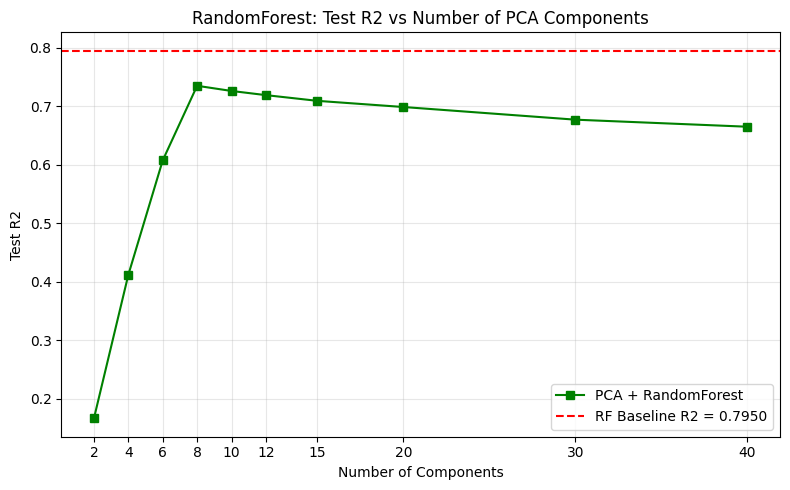

RF smallest matching components: None
(LR smallest was: 8)


In [9]:
# Baseline: RandomForest on all 60 features
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_baseline.fit(X_train_scaled, y_train)
rf_baseline_r2 = r2_score(y_test, rf_baseline.predict(X_test_scaled))
print(f'RF Baseline R2 (all 60 features): {rf_baseline_r2:.4f}')

# RF across component counts
rf_r2_scores = []
for n in component_counts:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
    rf.fit(X_train_pca, y_train)
    r2 = r2_score(y_test, rf.predict(X_test_pca))
    rf_r2_scores.append(r2)
    print(f'n_components={n:>3d}  ->  RF Test R2 = {r2:.4f}')

# Plot
plt.figure(figsize=(8, 5))
plt.plot(component_counts, rf_r2_scores, marker='s', label='PCA + RandomForest', color='green')
plt.axhline(y=rf_baseline_r2, color='r', linestyle='--', label=f'RF Baseline R2 = {rf_baseline_r2:.4f}')
plt.xlabel('Number of Components')
plt.ylabel('Test R2')
plt.title('RandomForest: Test R2 vs Number of PCA Components')
plt.xticks(component_counts)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Smallest matching for RF
rf_smallest = None
for n, r2 in zip(component_counts, rf_r2_scores):
    if r2 >= rf_baseline_r2 - 0.01:
        rf_smallest = n
        break
print(f'RF smallest matching components: {rf_smallest}')
print(f'(LR smallest was: {smallest_match})')

**Bonus explanation:** The tree-based model may need a different number of components than the linear model because RandomForest builds decision rules that split on individual features, while Linear Regression uses a weighted sum of all features simultaneously. PCA produces components that are linear combinations of the original features — these new axes are optimal for linear models (which operate in the original continuous space) but can scramble the axis-aligned splits that trees rely on. Because trees are already robust to irrelevant features (they simply won't split on them), reducing dimensionality with PCA offers less benefit and may even remove useful nonlinear structure the trees could have exploited. This reflects the linear-vs-tree sensitivity distinction: linear models are highly sensitive to multicollinearity and feature count (PCA helps a lot), while tree-based models are relatively insensitive to correlated features and are more affected when their axis-aligned feature space is rotated by PCA.